In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "swanson_7K_pbmc_teaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    default_assay="RNA",
    nthreads=4,
)

Downloading bucket files: 475687619 / 475687619 complete

Downloading bytes: 475687619 / 475687619 complete

In [2]:
assay_inventory = []
for assay_name in ("RNA", "ATAC", "ADT"):
    assay = ds.get_assay(assay_name)
    assay_inventory.append(
        {
            "assay": assay_name,
            "cells": assay.rawData.shape[0],
            "raw features": assay.rawData.shape[1],
            "active features": int(assay.feats.fetch_all("I").sum()),
        }
    )

pd.DataFrame(assay_inventory)

,assay,cells,raw features,active features
0,RNA,7069,36601,13345
1,ATAC,7069,240122,160049
2,ADT,7069,46,45


In [3]:
active_cells = int(ds.cells.fetch_all("I").sum())
pd.Series(
    {
        "source cells retained": ds.cells.N,
        "active exact W3 matches": active_cells,
        "Figure 4 W3 labels": 6_333,
        "Figure 4 labels absent from the pinned RDS": 139,
    }
)

source cells retained                         7069
active exact W3 matches                       6194
Figure 4 W3 labels                            6333
Figure 4 labels absent from the pinned RDS     139
dtype: int64

In [4]:
preprocessing = pd.DataFrame(
    [
        {
            "assay": "RNA",
            "normalization": "library-size log1p",
            "feature selection": "2,000 HVGs",
            "reduction": "30-component PCA",
        },
        {
            "assay": "ATAC",
            "normalization": "TF-IDF",
            "feature selection": "25,000 prevalent peaks",
            "reduction": "30-component streaming LSI, first component skipped",
        },
        {
            "assay": "ADT",
            "normalization": "CLR",
            "feature selection": "exclude isotype control",
            "reduction": "15-component PCA",
        },
    ]
)
preprocessing

,assay,normalization,feature selection,reduction
0,RNA,library-size log1p,"2,000 HVGs",30-component PCA
1,ATAC,TF-IDF,"25,000 prevalent peaks","30-component streaming LSI, first component sk..."
2,ADT,CLR,exclude isotype control,15-component PCA


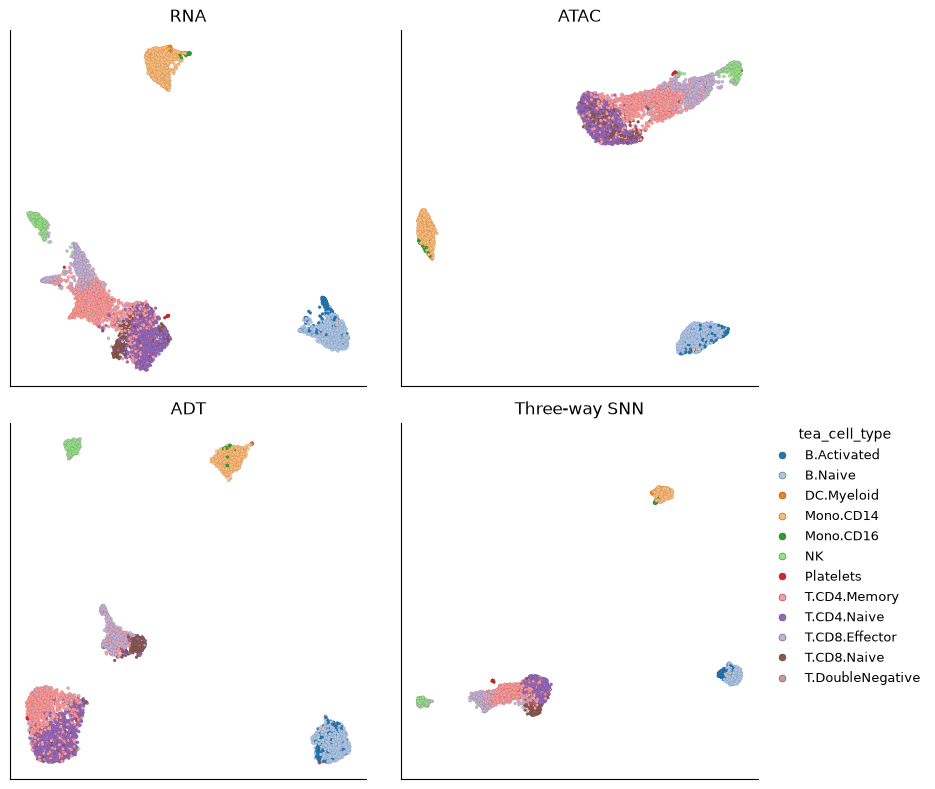

In [5]:
figure, axes = plt.subplots(2, 2, figsize=(10, 8))
layout_panels = (
    ("RNA", "RNA_UMAP"),
    ("ATAC", "ATAC_UMAP"),
    ("ADT", "ADT_UMAP"),
    ("Three-way SNN", "RNA+ATAC+ADT_UMAP"),
)
for index, (axis, (title, layout_key)) in enumerate(
    zip(axes.flat, layout_panels, strict=True)
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by="tea_cell_type",
        point_size=5,
        legend_loc="right",
        show_legend=index == len(layout_panels) - 1,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()

In [6]:
assays = ["RNA", "ATAC", "ADT"]
existing_wnn = next(
    ref
    for ref in ds.list_artifacts(
        scope="datastore",
        kind="integrated_graph",
        complete_only=True,
    )
    if (ds.inspect_artifact(ref).execution_options or {}).get("label")
    == "RNA+ATAC+ADT_wnn"
)
reused_wnn = ds.integrate_assays(
    assays=assays,
    label="RNA+ATAC+ADT_wnn",
    method="wnn",
    l2_normalize=True,
)
wnn_status = ds.inspect_artifact(reused_wnn)

assert reused_wnn == existing_wnn
assert wnn_status.parameters["assays"] == assays
pd.Series(
    {
        "artifact reused": reused_wnn == existing_wnn,
        "artifact id": reused_wnn.artifact_id,
        "complete": wnn_status.complete,
    }
)

artifact reused                                                 True
artifact id        4476be95c42c9d67f46c78050c0529ff2482b810cc9cd2...
complete                                                        True
dtype: object

In [7]:
weight_columns = [
    f"RNA+ATAC+ADT_wnn_{assay}_weight" for assay in assays
]
weight_values = np.column_stack(
    [ds.cells.fetch(column, key="I") for column in weight_columns]
)

assert weight_values.shape == (6_194, 3)
assert np.isfinite(weight_values).all()
assert (weight_values >= 0).all()
assert np.allclose(weight_values.sum(axis=1), 1, atol=1e-6)

pd.Series(
    {
        "shape": str(weight_values.shape),
        "minimum weight": float(weight_values.min()),
        "maximum weight": float(weight_values.max()),
        "maximum row-sum error": float(
            np.abs(weight_values.sum(axis=1) - 1).max()
        ),
    }
)

shape                    (6194, 3)
minimum weight                 0.0
maximum weight                 1.0
maximum row-sum error          0.0
dtype: object

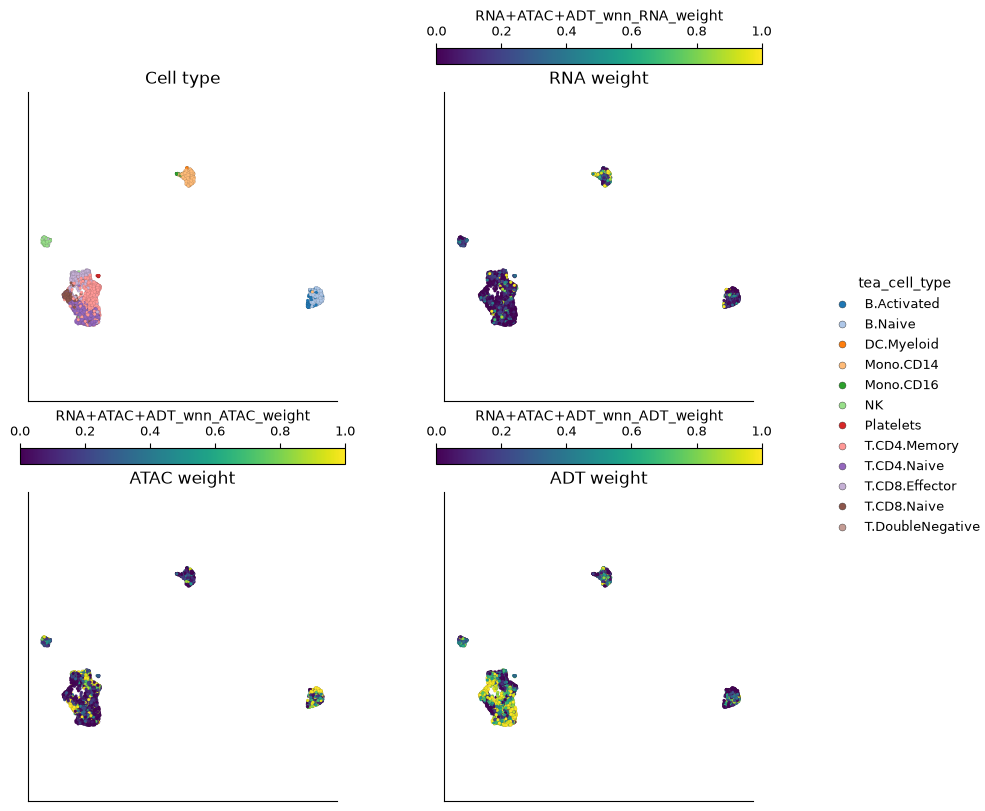

In [8]:
wnn_view = ds.plots.embedding(
    layout_key="RNA+ATAC+ADT_wnn_UMAP",
    color_by=["tea_cell_type", *weight_columns],
    n_columns=2,
    point_size=5,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    wnn_view.axes.values(),
    ("Cell type", "RNA weight", "ATAC weight", "ADT weight"),
    strict=True,
):
    axis.set_title(title)
wnn_view.figure.set_size_inches(10, 8)